<a href="https://colab.research.google.com/github/acarbegum/acarbegum/blob/main/Colab_Aboneli%C4%9Finizden_En_%C4%B0yi_%C5%9Eekilde_Yararlanma_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Aboneliğinizden En İyi Şekilde Yararlanma



--- 1. Adım: Veri Okuma ve Temizleme (EDA) ---
Veri seti başarıyla yüklendi. Boyut: (156, 9)
Harika! Veri setinde eksik değer bulunmuyor.

Verinin İlk 5 Satırı:
   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0.153   
1                    0.996                         0.592       0.252   
2                    1.028                         0.603       0.271   
3                    1.026                         0.591       0.354   
4                    0

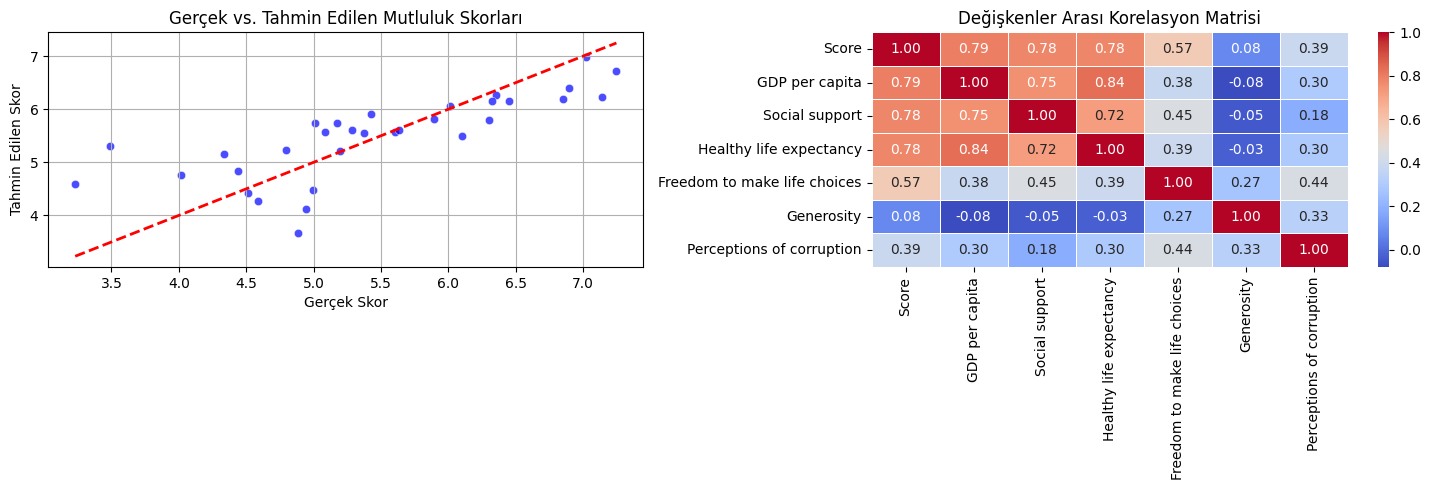

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


class HappinessPredictorPipeline:

    def __init__(self, file_path):
        """Pipeline sınıfını başlatır ve dosya yolunu alır."""
        self.file_path = file_path
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.model = None
        self.predictions = None

    # --- 1. ADIM: VERİ OKUMA VE TEMİZLEME (EDA) ---
    def load_and_clean_data(self):
        """Veriyi okur, eksik/hatalı değerleri kontrol eder ve temel EDA

        işlemlerini yapar.
        """
        print("--- 1. Adım: Veri Okuma ve Temizleme (EDA) ---")

        if not os.path.exists(self.file_path):
            raise FileNotFoundError(f"Dosya bulunamadı: {self.file_path}")

        # Veriyi yükleme
        self.df = pd.read_csv(self.file_path)
        print(f"Veri seti başarıyla yüklendi. Boyut: {self.df.shape}")

        # Sütun isimlerindeki olası boşlukları temizleme
        self.df.columns = self.df.columns.str.strip()

        # Eksik veri kontrolü
        missing_values = self.df.isnull().sum().sum()
        if missing_values > 0:
            print(f"Veride {missing_values} adet eksik değer bulundu, siliniyor...")
            self.df.dropna(inplace=True)
        else:
            print("Harika! Veri setinde eksik değer bulunmuyor.")

        # Temel İstatistiksel Özet
        print("\nVerinin İlk 5 Satırı:")
        print(self.df.head())

        print("\nİstatistiki Özet:")
        print(self.df.describe().T)

        return self.df

    # --- 2. ADIM: VERİYİ HAZIRLAMA VE EĞİTME ---
    def prepare_and_train(self, target_column="Score", test_size=0.2, random_state=42):
        """Hedef değişken ve özellikleri ayırır, veriyi ölçeklendirir ve

        modeli eğitir.
        """
        print("\n--- 2. Adım: Veriyi Hazırlama ve Eğitme ---")

        # Özellikleri (Features) ve Hedef Değişkeni (Target) Belirleme
        # Tahminde kullanılmayacak kategorik veya sıralama sütunlarını çıkarıyoruz
        ignore_cols = ["Overall rank", "Country or region", target_column]
        features = [col for col in self.df.columns if col not in ignore_cols]

        X = self.df[features]
        y = self.df[target_column]

        print(
            f"Kullanılan Özellikler (Features): {features}"
        )
        print(f"Hedef Değişken (Target): {target_column}")

        # Veriyi Train/Test olarak bölme
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Özellik Ölçeklendirme (Feature Scaling)
        scaler = StandardScaler()
        self.X_train_scaled = scaler.fit_transform(self.X_train)
        self.X_test_scaled = scaler.transform(self.X_test)

        # Model Eğitimi (Linear Regression)
        self.model = LinearRegression()
        self.model.fit(self.X_train_scaled, self.y_train)
        print("Linear Regression modeli başarıyla eğitildi.")

        # Tahminleri üretme
        self.predictions = self.model.predict(self.X_test_scaled)

    # --- 3. ADIM: ÇIKTI VERME VE GÖRSELLEŞTİRME ---
    def evaluate_and_visualize(self):
        """Model performans çıktılarını raporlar ve grafikleri çizer."""
        print("\n--- 3. Adım: Çıktı Verme ve Görselleştirme ---")

        # Metriklerin Hesaplanması
        mse = mean_squared_error(self.y_test, self.predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(self.y_test, self.predictions)
        r2 = r2_score(self.y_test, self.predictions)

        print(f"Model Performans Sonuçları:")
        print(f"-> Mean Absolute Error (MAE): {mae:.4f}")
        print(f"-> Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"-> R-squared (R² Score): {r2:.4f} (Model verinin %{r2*100:.1f}'ini açıklayabiliyor.)")

        # Özellik Katsayıları (Feature Importance)
        ignore_cols = ["Overall rank", "Country or region", "Score"]
        features = [col for col in self.df.columns if col not in ignore_cols]
        coefficients = pd.DataFrame(
            {"Özellik": features, "Katsayı (Etki)": self.model.coef_}
        ).sort_values(by="Katsayı (Etki)", ascending=False)

        print("\nMutluluk Skorunu En Çok Etkileyen Faktörler (Model Katsayıları):")
        print(coefficients.to_string(index=False))

        # --- GRAFİKLER ---
        plt.figure(figsize=(15, 5))

        # 1. Grafik: Gerçek vs Tahmin Edilen Değerler
        plt.subplot(1, 2, 1)
        sns.scatterplot(x=self.y_test, y=self.predictions, color="blue", alpha=0.7)
        plt.plot(
            [self.y_test.min(), self.y_test.max()],
            [self.y_test.min(), self.y_test.max()],
            "r--",
            lw=2,
        )
        plt.title("Gerçek vs. Tahmin Edilen Mutluluk Skorları")
        plt.xlabel("Gerçek Skor")
        plt.ylabel("Tahmin Edilen Skor")
        plt.grid(True)

        # 2. Grafik: Korelasyon Matrisi (EDA çıktısı olarak)
        plt.subplot(1, 2, 2)
        numeric_df = self.df.select_dtypes(include=[np.number]).drop(
            columns=["Overall rank"], errors="ignore"
        )
        corr_matrix = numeric_df.corr()
        sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Değişkenler Arası Korelasyon Matrisi")

        plt.tight_layout()
        plt.show()


# --- PIPELINE'I ÇALIŞTIRMA ---
if __name__ == "__main__":
    # Dosya adını belirtiyoruz (Aynı çalışma dizininde olduğu varsayılmıştır)
    file_name = "2019.csv"

    # Pipeline nesnesini oluşturma
    pipeline = HappinessPredictorPipeline(file_path=file_name)

    try:
        # 1. Adım: EDA ve Temizlik
        pipeline.load_and_clean_data()

        # 2. Adım: Hazırlık ve Eğitim
        pipeline.prepare_and_train(target_column="Score")

        # 3. Adım: Sonuçlar ve Görselleştirme
        pipeline.evaluate_and_visualize()

    except Exception as e:
        print(f"Bir hata oluştu: {e}")

# Google Colab artık VS Code'da kullanılabilir.
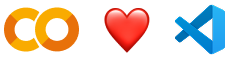

Visual Studio Code için yeni <a href="https://marketplace.visualstudio.com/items?itemName=Google.colab">Google Colab uzantısını</a> deneyin. Birkaç tıklamayla kullanmaya başlayabilirsiniz:

*  VS Code'da <strong><em>Uzantılar</em></strong> görünümünü açın ve "Google Colab"i arayarak uzantıyı yükleyin.
*  Yerel çalışma alanınızda herhangi bir <code>.ipynb</code> not defteri dosyası oluşturun veya açın ve bir hücreyi çalıştırarak ya da sağ üstteki <strong><em>Çekirdek Seç</em></strong> düğmesini tıklayarak çekirdek seçiciyi açın.
*  <strong><em>Colab</em></strong>'i tıklayın, istediğiniz çalışma zamanını seçin ve Google Hesabınızla oturum açın. Artık hazırsınız.

Daha fazla ayrıntı için <a href="https://developers.googleblog.com/google-colab-is-coming-to-vs-code">duyurunun yapıldığı blogumuzu buradan</a> inceleyin.

# Access Popular LLMs via Google-Colab-AI Without an API Key

Users with Colab's paid plans have free access to most popular LLMs via google-colab-ai Python library. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).

In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")
print(response)

## Daha hızlı GPU'lar

<p>Colab'in ücretli planlarından birini satın alan kullanıcılar daha hızlı GPU'lara ve daha fazla belleğe erişebilirler. Not defterinizin GPU ayarlarını menüdeki <code>Çalışma zamanı &gt; Çalışma zamanı türünü değiştir</code> bölümünden yükselterek çeşitli hızlandırıcı seçeneklerinden &#40;kullanım durumuna bağlı olarak&#41; yararlanabilirsiniz.</p>
<p>Colab'in ücretsiz sürümü, kota kısıtlamalarına ve kullanılabilirlik durumuna bağlı olarak Nvidia'nın T4 GPU'larına erişim imkanı sunar.</p>

İstediğiniz zaman aşağıdaki hücreyi yürüterek size hangi GPU'nun atandığını görebilirsiniz. Aşağıdaki kod hücresi çalıştırıldığında sonuç olarak "Not connected to a GPU" &#40;GPU'ya bağlanılamadı&#41; mesajı görüntüleniyorsa menüde <code>Çalışma zamanı &gt; Çalışma zamanı türünü değiştir</code> bölümünden çalışma zamanını değiştirerek bir GPU hızlandırıcıyı etkinleştirebilir, sonra da hücreyi yeniden çalıştırabilirsiniz.

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Not defterinizle GPU kullanmak için <code>Çalışma zamanı &gt; Çalışma zamanı türünü değiştir</code> menüsünü seçip donanım hızlandırıcıyı istediğiniz seçeneğe ayarlayın.

## Daha yüksek bellek kapasitesi

Colab'in ücretli planlarından birini satın alan kullanıcılar, kullanılabilir olduğunda yüksek bellek kapasiteli sanal makinelere erişebilirler. Daha güçlü GPU'lar her zaman yüksek bellek kapasiteli sanal makinelerle birlikte sunulur.
Aşağıdaki kod hücresini çalıştırarak istediğiniz zaman ne kadar belleğinizin kaldığını görebilirsiniz. Aşağıdaki kod hücresi çalıştırıldığında sonuç olarak "Not using a high-RAM runtime" &#40;Yüksek RAM'li çalışma zamanı kullanılmıyor&#41; mesajı görüntüleniyorsa menüde <code>Çalışma zamanı &gt; Çalışma zamanı türünü değiştir</code> bölümünden yüksek RAM'li bir çalışma zamanı etkinleştirebilirsiniz. Ardından, "Çalışma zamanı şekli" açma/kapatma düğmesinden Yüksek RAM'i seçin. Ardından, kod hücresini yeniden çalıştırın.

In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

## Daha uzun çalışma zamanları

Tüm Colab çalışma zamanları belirli bir süre sonra sıfırlanır &#40;çalışma zamanı tarafından kod yürütülmüyorsa bu süre kısalır&#41;. Colab Pro ve Pro+ kullanıcılarının çalışma zamanı, Colab'i ücretsiz kullananlara göre daha uzundur.

## Arka planda yürütme

Colab Pro+ kullanıcılarının arka planda yürütme işlevine erişimi vardır. Burada not defterleri, tarayıcı sekmesi kapatıldıktan sonra bile çalışmaya devam eder. Kullanılabilir işlem birimleriniz olduğu sürece bu işlev, Pro+ çalışma zamanlarında her zaman etkindir.


## Colab Pro'da kaynak sınırlarını gevşetme

Colab'de kaynaklarınız sınırsız değildir. Colab'den en iyi şekilde faydalanmak için ihtiyacınız olmayan kaynakları kullanmaktan kaçının. Örneğin, sadece gerektiğinde GPU kullanın ve işiniz bittiğinde Colab sekmelerini kapatın.

Sınırlamalarla karşılaşırsanız Pay As You Go ile daha fazla işlem birimi satın alarak bu sınırlamaları gevşetebilirsiniz. Herkes <a href="https://colab.research.google.com/signup">Pay As You Go</a> ile işlem birimi satın alabilir. Abonelik gerekmez.

## Görüşlerinizi bildirin

<p>Geri bildiriminiz varsa lütfen bize iletin. Geri bildirim göndermenin en iyi yolu, Yardım &gt; "Geri bildirim gönder..." menüsünü kullanmaktır. Colab Pro'da kullanım sınırıyla karşılaşırsanız Pro+'a abone olmayı düşünebilirsiniz.</p>
<p>Colab Pro, Pro+ ya da Pay As You Go ile ilgili faturalandırma &#40;ödemeler&#41; konusunda hatalarla veya başka sorunlarla karşılaşırsanız lütfen <a href="mailto:colab-billing@google.com">colab-billing@google.com</a> adresine e-posta gönderin.</p>

## Diğer Kaynaklar

### Colab'de Not Defterleriyle Çalışma
- [Colab'e genel bakış](/notebooks/basic_features_overview.ipynb)
- [Markdown rehberi](/notebooks/markdown_guide.ipynb)
- [Kitaplıkları içe aktarma ve bağımlıları yükleme](/notebooks/snippets/importing_libraries.ipynb)
- [GitHub'da not defteri kaydetme ve yükleme](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Etkileşimli formlar](/notebooks/forms.ipynb)
- [Etkileşimli widget'lar](/notebooks/widgets.ipynb)

<a name="working-with-data"></a>
### Verilerle Çalışma
- [Veri yükleme: Drive, E-Tablolar ve Google Cloud Storage](/notebooks/io.ipynb)
- [Grafikler: Veri görselleştirme](/notebooks/charts.ipynb)
- [BigQuery'yi kullanmaya başlama](/notebooks/bigquery.ipynb)

### Makine Öğrenimi Hızlandırılmış Kursu
Google'ın online Makine Öğrenimi kursundan birkaç not defterini burada bulabilirsiniz. Daha fazlası için <a href="https://developers.google.com/machine-learning/crash-course/">tam kurs web sitesine</a> bakın.
- [Pandas DataFrame'e giriş](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Pandas'ı hızlandırmak için RAPIDS cuDF'ye giriş](https://nvda.ws/rapids-cudf)
- [cuML'nin hızlandırıcı modunu kullanmaya başlama](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)


<a name="using-accelerated-hardware"></a>
### Hızlandırılmış Donanım Kullanma
- [Flax NNX API kullanarak MNIST veri kümesindeki el yazısıyla yazılmış rakamları sınıflandırmak için bir CNN eğitin](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [JAX ile görüntü sınıflandırma için bir Vision Transformer &#40;ViT&#41; eğitin](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [JAX kullanarak dönüştürücü dil modeliyle metin sınıflandırma](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<a name="machine-learning-examples"></a>

## Makine Öğrenimi Örnekleri

Öne çıkan birkaç örnek:

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">JAX AI Stack ile bir miniGPT dil modelini eğitin</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Tunix kullanarak LLM için LoRA/QLoRA ince ayarı</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">LoRA ve QLoRA ile Gemma'nın parametre açısından verimli ince ayarı</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Hugging Face dönüştürücüleri kontrol noktalarını yükleme</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Keras'ta 8 bitlik tam sayı nicemleme</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Basit bir dönüştürücü modeliyle Float8 eğitimi ve çıkarımı</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">KerasHub ile dönüştürücüye sıfırdan ön eğitim verme</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Basit MNIST evrişimli sinir ağı</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Keras 3 kullanarak sıfırdan görüntü sınıflandırma</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">KerasHub ile görüntü sınıflandırma</a>
